# Long-Term Trends

<div class="page-subtitle">
Quantifying Climate Change Across Space and Time
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/12_L10_time-series/08_computing_trends.ipynb)

---

```{admonition} Big idea
:class: tip

A trend map is not just a picture of change. It is the result of fitting a statistical model through time at every single pixel. By quantifying the slope of this model, we transition from observing patterns to measuring the rate of environmental change.
```

In previous chapters, we reduced the time dimension using aggregations and rolling averages. Now, we will extract the actual rate of change. We will move beyond visual inspection and apply mathematical modeling to our data cubes to quantify exactly how fast our environment is changing.

**Applied Scenario**
We will continue using the NOAA Extended Reconstructed Sea Surface Temperature dataset. Our goal is to calculate the linear rate of ocean warming over the last century, interpret the mathematical baseline of our models, and ultimately apply harmonic regression to see how the Earth's seasonal cycle influences our long-term trend estimates.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Load the historical sea surface temperature dataset
ds = xr.tutorial.open_dataset("ersstv5")

---

## 1. The Mathematics of Change

In the [previous chapter](https://hendrikwulf.github.io/sds210-jb/book/l10-time-series/temporal-aggregation/#id-2-resampling-changing-time-frequency), we observed that the global sea surface temperature (SST) increase followed an approximately linear trajectory. Visualizing your data is always a crucial first step before committing to a specific statistical trend model. 

While we will focus on linear trends, there are several more complex models used in environmental data science depending on the behavior of the data:
* **Polynomial Regression:** Fits curves (such as quadratic or cubic equations) to data where the rate of change is actively accelerating or decelerating over time.
* **Harmonic Regression:** Uses sine and cosine functions to model highly cyclical patterns, well suited for raw time series where the seasonal cycle has not been removed.
* **Non-parametric Smoothing (e.g., LOESS):** Fits localized curves to data to visualize underlying patterns without forcing a single global mathematical equation.

Before we scale up to entire maps, we need to understand the core idea: a trend is the result of fitting a straight line through data over time. When we talk about long-term climate trends, we typically refer to time series of 30 years or more. In this example, we use **linear regression** as a simple and robust method for quantifying these trends. We want to fit a straight line through our noisy temporal data. 

The equation for a straight line is modeled as:
$$y=mx+b$$

* **$y$** (value) is our observed variable, such as temperature.
* **$x$** (time) is our time index.
* **$b$** (intercept) is the value at the beginning of the time series.
* **$m$** (slope) represents how fast the variable changes over time.

### Visual Intuition
In climate science, the slope is the most critical component. It transforms a complex time series into a single, highly interpretable number describing environmental change.

* **Positive slope:** An increasing trend (e.g., warming). A steep slope means rapid change.
* **Negative slope:** A decreasing trend (e.g., cooling).
* **Zero slope:** A flat line, meaning the variable is stable over time with little to no long-term change.

```{admonition} Key Insight
:class: note

A trend map is not just a picture of change. It is the result of fitting this simple statistical model ($y=mx+b$) through time at *every single pixel*. 
```

<iframe 
    src="https://hendrikwulf.github.io/sds210_assets_L10_ch08_linear_regression_visualizer/"
    width="100%"
    title="Interactive Linear Regression Explorer"
    frameborder="0"
    style="height: 650px; min-height: 650px; border: none; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);"
    allowfullscreen>
</iframe>

*For an alternative standalone version of the explorer, follow this [link](https://hendrikwulf.github.io/sds210_assets_L10_ch08_linear_regression_visualizer/).*

---

## 2. Point Based Trends First

Before we run a calculation across the entire globe, it is always best practice to test our statistical model on a single point. This ensures we understand the inputs and outputs before scaling up. 

We will select a single coordinate in the North Atlantic and use `xarray`'s built-in `.polyfit()` method. The `deg=1` argument specifies that we want a first-degree polynomial, which is a straight line.

In [2]:
# Extract a single point time series
point_data = ds.sst.sel(lon=300, lat=50)

# Fit a linear trend (degree 1) along the time dimension
point_trend = point_data.polyfit(dim="time", deg=1)
point_trend

<xarray.Dataset> Size: 32B
Dimensions:               (degree: 2)
Coordinates:
  * degree                (degree) int64 16B 1 0
Data variables:
    polyfit_coefficients  (degree) float64 16B 1.304e-18 3.707

The output is a new dataset containing `polyfit_coefficients`. This array has a new dimension called `degree`. The value at `degree=1` is our slope, and the value at `degree=0` is our intercept.

### Visualizing the point trend

To verify that our model worked, we can use `xarray.polyval()` to evaluate those coefficients and generate the actual trend line, which we can then plot over our raw observations.

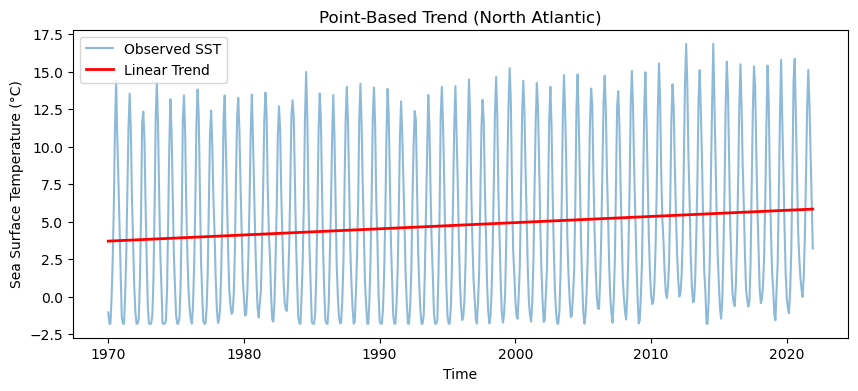

In [3]:
# Evaluate the polynomial coefficients along the time dimension to create the line
trend_line = xr.polyval(point_data.time, point_trend.polyfit_coefficients)

# Plot both the original observations and the fitted trend
plt.figure(figsize=(10, 4))
point_data.plot(label="Observed SST", alpha=0.5)
trend_line.plot(label="Linear Trend", color="red", linewidth=2)

plt.title("Point-Based Trend (North Atlantic)")
plt.ylabel("Sea Surface Temperature (°C)")
plt.legend()
plt.show()

<div class="figure-caption-like">
A 1D time series for a single coordinate in the North Atlantic. The faded blue line represents the raw monthly observations, while the solid black line represents the linear regression model fitted through the data.
</div>

```{admonition} What just happened?
:class: note

We reduced an entire time series to a single mathematical equation, where the slope represents the definitive rate of change. This is the foundation of trend analysis. 
```

---

## 3. Pixel Wise Polyfit

Now we scale up from a single point to all pixels. Because `xarray` is designed for multidimensional arrays, scaling up to the entire planet requires no manual loop structures. Instead, we use **vectorized operations** across the time dimension. 

We apply the exact same function to our master dataset, and `xarray` broadcasts the linear regression across every pixel simultaneously.

In [4]:
# Fit a linear trend across the time dimension for every pixel globally
global_trend = ds.sst.polyfit(dim="time", deg=1)

# Extract just the slope (coefficient of degree 1) for our trend map
slope = global_trend.polyfit_coefficients.sel(degree=1)

To truly appreciate what just happened, let us take an immediate visual peek at the resulting slope array. Even before we convert the mathematical units into something readable, we can map the raw values using a diverging colormap (`RdBu_r`) and `robust=True` to automatically handle outliers.

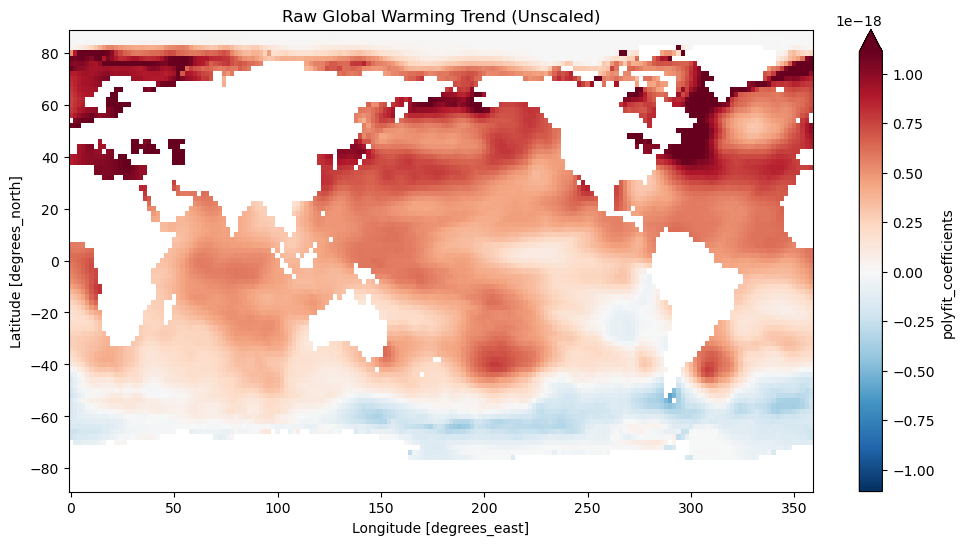

In [5]:
plt.figure(figsize=(12, 6))
slope.plot(cmap="RdBu_r", robust=True)

plt.title("Raw Global Warming Trend (Unscaled)")
plt.show()

<div class="figure-caption-like">
A global map of the raw regression slope. Without writing a single loop, we instantly generated a visual representation of warming (red) and cooling (blue) trends across the entire Earth.
</div>

You have just computed tens of thousands of individual linear regression models in a single line of code. This is the power of labeled multidimensional arrays and vectorized operations.

---

## 4. Interpreting the Slope

When calculating a trend, the slope inherently has units of **Variable per Time Step** (e.g., °C per time step). But what exactly is a single time step in our dataset?

We must discuss units carefully. When you feed `datetime64` coordinate objects into `xarray.polyfit()`, the underlying algorithm automatically converts the dates into nanoseconds to perform the continuous math. Therefore, the raw slope returned by our function is currently measured in **degrees Celsius per nanosecond**. 

A temperature change per nanosecond is infinitely small and scientifically meaningless to read. We need to scale this slope into a standard, interpretable metric: **degrees Celsius per decade**.

In [6]:
# Define the number of nanoseconds in a standard year
ns_per_year = 1e9 * 60 * 60 * 24 * 365.25

# Convert the slope to degrees per year
slope_per_year = slope * ns_per_year

# Multiply by 10 to get the climate standard: degrees per decade
slope_per_decade = slope_per_year * 10

Now we have a highly interpretable variable. For example, if a pixel has a value of 0.2, it means that specific patch of ocean has been warming at a rate of 0.2°C every ten years.

### Visualizing the scaled trend

Let's plot our newly scaled data. Because our values now cross zero (featuring both warming and cooling), we must use a diverging colormap (like `RdBu_r`). Crucially, we must also pass `center=0` to ensure that 0°C/decade is perfectly mapped to white, allowing the red and blue colors to accurately represent warming and cooling.

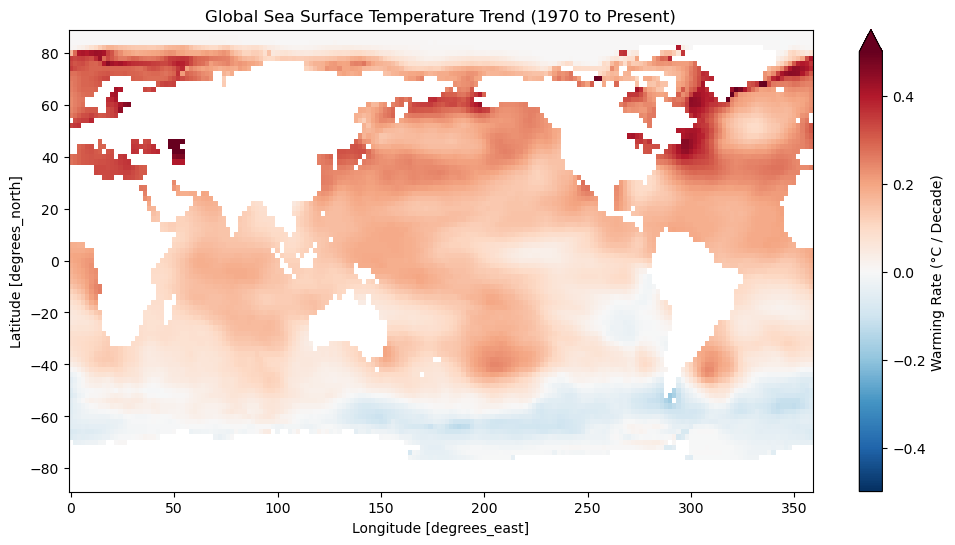

In [7]:
plt.figure(figsize=(12, 6))

slope_per_decade.plot(
    cmap="RdBu_r",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    cbar_kwargs={"label": "Warming Rate (°C / Decade)"},
)

plt.title("Global Sea Surface Temperature Trend (1970 to Present)")
plt.show()

<div class="figure-caption-like">
A global map showing the rate of sea surface temperature change in degrees Celsius per decade. By explicitly scaling our units and centering the diverging colormap on zero, the map clearly and accurately distinguishes between long-term warming regions (red) and cooling regions (blue).
</div>
```

---

## 5. Interpreting the Intercept

While the slope tells us how fast temperatures are changing, the intercept ($b$) tells us our starting point. But what exactly is the "start" of our time series mathematically?

When `xarray` converts `datetime64` objects to nanoseconds for the regression, it uses the standard Unix epoch. This means that mathematical time zero ($x=0$) is exactly **January 1, 1970**. Therefore, the intercept returned by our model represents the modeled sea surface temperature on that specific date.

It is important to distinguish between the start of your specific dataset and the start of the underlying time measurement. By pure chance, the time series we are analyzing might also begin on January 1, 1970. However, even if your dataset started in 1854 or 2000, the mathematical intercept calculated by `xarray` would still represent the modeled value on January 1, 1970, simply because of how the Unix epoch anchors the timeline.

Let us extract and visualize the intercept (where `degree=0`). Since these are absolute temperatures rather than diverging rates of change, we will use a sequential colormap like `viridis`.

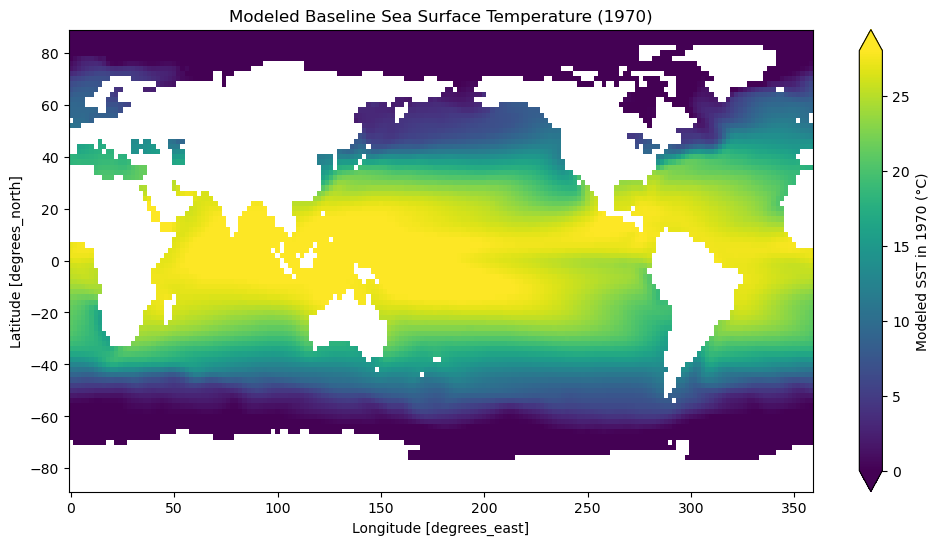

In [8]:
# Extract the intercept (degree=0) from our global trend model
intercept = global_trend.polyfit_coefficients.sel(degree=0)

# Plot the intercept as a spatial map
plt.figure(figsize=(12, 6))

intercept.plot(
    cmap="viridis", vmin=0, vmax=28, cbar_kwargs={"label": "Modeled SST in 1970 (°C)"}
)

plt.title("Modeled Baseline Sea Surface Temperature (1970)")
plt.show()

<div class="figure-caption-like">
A global map showing the regression intercept. Because time zero in the underlying math is 1970, this map represents the modeled spatial distribution of sea surface temperatures at the very start of that year.
</div>

### Why does this look like a normal temperature map?

You might notice that this intercept map closely resembles a standard global distribution of actual sea surface temperatures, with warm equators and cold poles. This is not a coincidence; it highlights a critical concept in climate data. 

The geographic variation in temperature across the Earth is enormous, often spanning more than 30°C from the equator to the freezing poles. In contrast, the long term climate trend we extracted earlier is relatively small (measured in fractions of a degree per decade). Because the climate change signal is so small compared to the massive spatial temperature gradient, the mathematical intercept mirrors the physical state of the ocean.


--- 

## 6. Modeling the Seasonal Cycle

In our previous examples, we relied on a simple linear regression to calculate long term trends. However, we lumped all the data together and ignored the inherent seasonal variations. 

What if we want to model the long-term trend while explicitly including these seasonal variations? To capture both a steady trend and a repeating seasonal cycle simultaneously, we use **harmonic regression**. This model combines a standard straight line with sine and cosine waves.

### The Mathematics of the Harmonic Model

The harmonic model is fitted to every pixel by estimating four distinct parameters. The equation takes the following form:

$$\hat{y}(t) = \beta_0 + \beta_1 t + \beta_2 \cos\left(2\pi \frac{t}{T}\right) + \beta_3 \sin\left(2\pi \frac{t}{T}\right)$$

* **$\beta_0$** (Intercept): The baseline value at the start of the time series.
* **$\beta_1$** (Linear Trend): The long term rate of change (e.g., global warming).
* **$\beta_2$ and $\beta_3$** (Harmonic Terms): These coefficients control the amplitude and phase of the seasonal cycle.
* **$T$** (Period): The length of one full cycle. Because our data follows an annual cycle, $T = 1$ year.

By fitting this model, we compress decades of complex spectral-temporal dynamics into just four interpretable numbers per pixel.

<iframe 
    src="https://hendrikwulf.github.io/sds210_assets_L10_ch08_harmonic_regression_visualizer/"
    width="100%"
    title="Interactive Harmonic Regression Explorer"
    frameborder="0"
    style="height: 720px; min-height: 720px; border: none; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);"
    allowfullscreen>
</iframe>

*For an alternative standalone version of the explorer, follow this [link](https://hendrikwulf.github.io/sds210_assets_L10_ch08_harmonic_regression_visualizer/).*

### Preparing the Time Coordinate

Unlike `.polyfit()`, which automatically converts dates to nanoseconds, `xarray` provides a more flexible `.curvefit()` method for custom models. For `.curvefit()` to work smoothly and for our period ($T=1$) to make mathematical sense, we need to convert our datetime coordinate into **fractional years** (e.g., July 1st, 1970 becomes 1970.5).

In [9]:
# Create a numeric time coordinate expressed as fractional years
fractional_year = ds.time.dt.year + (ds.time.dt.dayofyear / 365.25)

# Assign this new coordinate to our dataset
ds = ds.assign_coords(frac_year=("time", fractional_year.data))

### Point Based Harmonic Fit

Just as we did with the linear regression, we will start by fitting this complex model to a single grid cell in the North Atlantic. First, we define our mathematical model as a standard Python function.

In [10]:
import numpy as np


# Define the harmonic function
def harmonic_model(t, beta0, beta1, beta2, beta3):
    # Omega represents 2 * pi / T. Since T = 1 year, we just use 2 * pi.
    omega = 2 * np.pi
    return (
        beta0 + (beta1 * t) + (beta2 * np.cos(omega * t)) + (beta3 * np.sin(omega * t))
    )


# Extract our test pixel
point_data = ds.sst.sel(lon=300, lat=50)

# Fit the custom model along the fractional year coordinate
harmonic_fit = point_data.curvefit(
    coords=["frac_year"], func=harmonic_model, reduce_dims="time"
)

# View the four estimated parameters
harmonic_fit.curvefit_coefficients

<xarray.DataArray 'curvefit_coefficients' (param: 4)> Size: 32B
array([-6.91734399e+01,  3.70675692e-02, -6.03462224e+00, -4.32459282e+00])
Coordinates:
  * param    (param) <U5 80B 'beta0' 'beta1' 'beta2' 'beta3'
    lat      float32 4B 50.0
    lon      float32 4B 300.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

### Visualizing the Fitted Values

To understand how well our model fits the raw data, we can plug our estimated $\beta$ coefficients back into the `harmonic_model` function to generate the fitted curve.

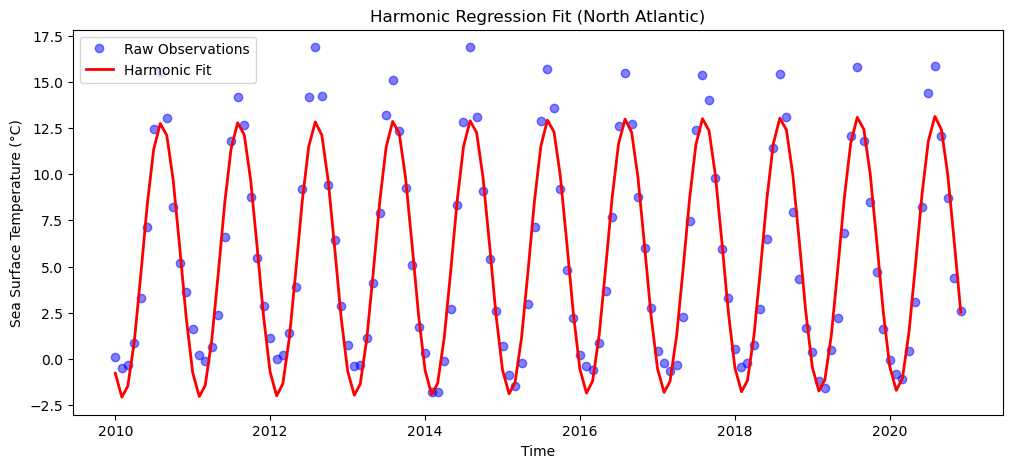

In [11]:
# Extract the estimated coefficients
coeffs = harmonic_fit.curvefit_coefficients

# Generate the modeled temperature curve
fitted_curve = harmonic_model(
    point_data.frac_year,
    coeffs.sel(param="beta0"),
    coeffs.sel(param="beta1"),
    coeffs.sel(param="beta2"),
    coeffs.sel(param="beta3"),
)

# Plot a recent subset of the data for clarity
plt.figure(figsize=(12, 5))

# Plot raw observations (2010 to 2020)
point_data.sel(time=slice("2010", "2020")).plot(
    marker="o", linestyle="none", color="blue", alpha=0.5, label="Raw Observations"
)

# Plot the harmonic fit
fitted_curve.sel(time=slice("2010", "2020")).plot(
    color="red", linewidth=2, label="Harmonic Fit"
)

plt.title("Harmonic Regression Fit (North Atlantic)")
plt.ylabel("Sea Surface Temperature (°C)")
plt.legend()
plt.show()

<div class="figure-caption-like">
A 10 year subset of sea surface temperatures in the North Atlantic. The blue dots represent the raw monthly observations, while the solid black line represents the fitted harmonic model, successfully capturing both the repeating seasonal oscillation and the underlying linear trend.
</div>

### Scaling to the Global Map

Just like `.polyfit()`, `.curvefit()` can be broadcast across the entire multidimensional array by calling it directly on `ds.sst`. 

*Note: Pixel-wise curve fitting is highly processing intensive. It requires the computer to run an optimization algorithm on tens of thousands of individual time series. If you run this globally, be prepared for it to take significantly longer than the simple linear regression!*

In [12]:
# Fit the harmonic model globally (this may take a minute or two)
global_harmonic = ds.sst.curvefit(
    coords=["frac_year"], func=harmonic_model, reduce_dims="time"
)

Once processed, visualizing the coefficients reveals drastically different patterns. Plotting $\beta_2$ or $\beta_3$ will reveal geographic maps of seasonal amplitude, highlighting regions with extreme summer to winter temperature swings. However, our primary interest is the long-term warming trend, which is captured by $\beta_1$.

### Visualizing the Harmonic Slope

Before we plot the map, we need to consider our units. This is a great opportunity to see how custom models differ from built-in functions. 

Because we manually defined our time coordinate (`frac_year`) in years, the $\beta_1$ slope is already calculated in **degrees Celsius per year**. Unlike the nanosecond conversion required for `.polyfit()`, we only need to multiply by 10 to reach our climate standard of degrees per decade.

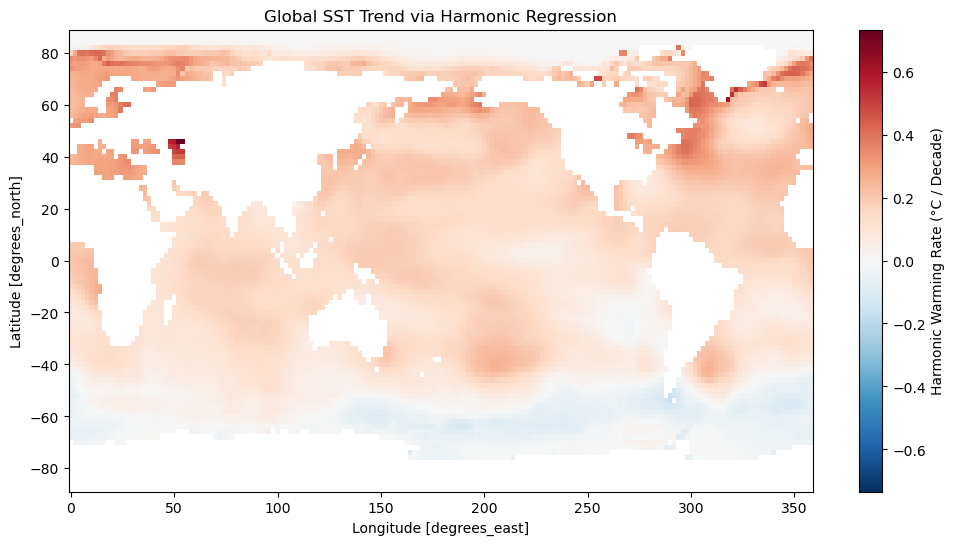

In [13]:
# Extract the linear trend parameter (beta1)
harmonic_slope_raw = global_harmonic.curvefit_coefficients.sel(param="beta1")

# Scale from degrees/year to degrees/decade
harmonic_slope_decade = harmonic_slope_raw * 10

# Plot the harmonic slope map
plt.figure(figsize=(12, 6))

harmonic_slope_decade.plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Harmonic Warming Rate (°C / Decade)"},
)

plt.title("Global SST Trend via Harmonic Regression")
plt.show()

<div class="figure-caption-like">
A global map showing the rate of sea surface temperature change computed via harmonic regression. Because the model explicitly isolates the seasonal cycle, the $\beta_1$ parameter provides a highly robust estimate of the underlying long-term warming (red) and cooling (blue) trends.
</div>

---

## 7. Comparing the Models

We have now calculated the global warming trend using two different methods on the raw dataset:
1. **Simple Linear Regression** (`.polyfit()`): Fits a straight line through the raw, seasonally noisy data.
2. **Harmonic Regression** (`.curvefit()`): Fits a straight line while simultaneously modeling the seasonal sine and cosine waves.

Which one is better? Let us compute the mathematical difference between the two slopes to see if accounting for seasonality changed our trend estimates.

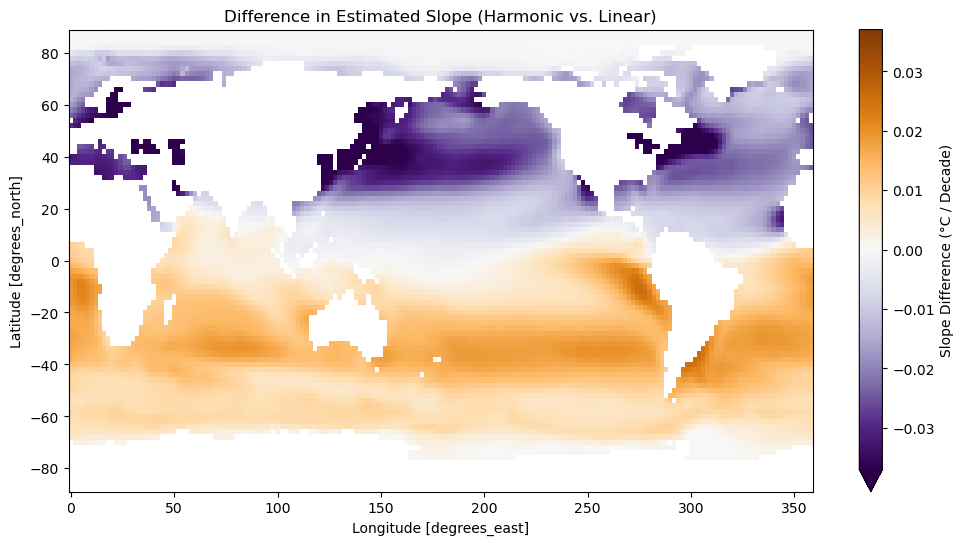

In [14]:
# Calculate the difference between the two models
slope_difference = harmonic_slope_decade - slope_per_decade

# Plot the difference using a different diverging colormap
plt.figure(figsize=(12, 6))

slope_difference.plot(
    cmap="PuOr_r",
    center=0,
    robust=True,
    cbar_kwargs={"label": "Slope Difference (°C / Decade)"},
)

plt.title("Difference in Estimated Slope (Harmonic vs. Linear)")
plt.show()

<div class="figure-caption-like">
A map of the mathematical difference between the harmonic and linear regression slopes. Purple areas indicate where the harmonic model estimated a more positive trend, while orange areas indicate where the linear model estimated a more positive trend.
</div>


### Interpreting the Difference

Looking at the map, you will immediately notice that the difference between the two models is not just random noise. Instead, there is a striking, hemisphere-wide pattern: the Northern Hemisphere is predominantly purple (where the linear model estimated a higher trend), while the Southern Hemisphere is predominantly orange (where the harmonic model estimated a higher trend).

Why do the hemispheres show opposite biases? The answer lies in the seasons.

The Northern and Southern hemispheres experience summer and winter exactly six months out of phase. If a dataset starts or ends during a specific time of year (for example, ending in December when the North is cold and the South is warm), a simple linear regression gets "tricked" by these final data points. It interprets the normal seasonal high or low at the end of the time series as part of the overall trajectory, slightly skewing the long-term slope up or down.

Because the harmonic model explicitly calculates the sine and cosine waves of the seasonal cycle, it is immune to this start- and end-date bias. It mathematically separates the seasonal phase from the long-term trend. This hemisphere-scale map perfectly illustrates why harmonic regression is considered the more rigorous approach when analyzing raw, non-anomalous environmental data.

---

## 8. Exercise: Seasonal Trend Analysis

**Task:** Combine the temporal grouping skills you learned in the previous chapter with your new trend-fitting skills. Your goal is to map the long-term warming trend specifically for the month of **January**.

1. **Filter:** Select only the January data from the original `ds.sst` dataset. *(Hint: Use `.sel()` combined with the `.dt` accessor for logical indexing, or use `.groupby("time.month")`)*.
2. **Model:** Fit a degree 1 polynomial to this January subset.
3. **Convert:** Extract the slope and convert it from nanoseconds to degrees Celsius per decade.
4. **Map:** Plot the resulting slope map using a diverging colormap explicitly centered on zero.
5. **Interpret:** Write two short sentences comparing your January map to the annual average map we created earlier.

**Starter code:**

In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Assume the dataset is already loaded in your environment
# ds = xr.tutorial.open_dataset("ersstv5")

# 1. Filter for January (Month 1)
# ...

# 2. Model the trend using polyfit
# ...

# 3. Convert units (nanoseconds to decades)
# ...

# 4. Map the results
# ...

````{admonition} Sample solution
:class: dropdown

```{code-cell} python
# 1. Filter for January (Month 1)
january_data = ds.sst.sel(time=ds.sst.time.dt.month == 1)

# 2. Model the trend
jan_trend = january_data.polyfit(dim="time", deg=1)
jan_slope_raw = jan_trend.polyfit_coefficients.sel(degree=1)

# 3. Convert units (nanoseconds to decades)
ns_per_year = 1e9 * 60 * 60 * 24 * 365.25
jan_slope_decade = (jan_slope_raw * ns_per_year) * 10

# 4. Map the results
plt.figure(figsize=(12, 6))
jan_slope_decade.plot(
    cmap="RdBu_r", 
    center=0, 
    vmin=-0.3, 
    vmax=0.3, 
    cbar_kwargs={"label": "January Warming Rate (°C / Decade)"}
)
plt.title("January Sea Surface Temperature Trend")
plt.show()
```

:::{figure} images/14_linear_SST_trend_Jan.png
:alt: A global map showing the rate of sea surface temperature change specifically for the month of January. The map uses a diverging red and blue color scale to highlight isolated warming and cooling regions that differ from the annual mean.
:width: 700px
:align: center
:::

**Interpretation:**
> While the January map largely mirrors the broad global warming pattern, it reveals intensified regional cooling in the Southern Ocean and the eastern Pacific. This highlights how specific seasonal extremes, such as austral summer conditions, can drive localized temperature changes that are otherwise muted in a year-round average.
````

---

## 9. Summary

By applying statistical models across multidimensional arrays, we can transition from observing temporal patterns to precisely measuring the rate of environmental change.

* **Pixel-Wise Modeling:** A trend map represents a statistical model computed at every single pixel simultaneously. Using `xarray`, this is achieved through vectorized operations rather than manual loops.
* **Unit Conversion:** When using `.polyfit()` with standard datetime coordinates, the slope is calculated in units per nanosecond and must be manually scaled to a meaningful metric (like degrees per decade).
* **Interpreting the Intercept:** The mathematical starting point ($x=0$) for `xarray` datetime regressions is the standard Unix epoch. Consequently, the intercept always represents the modeled baseline value on January 1, 1970.
* **Harmonic Regression:** While linear regression works well on anomalies, fitting raw data with a harmonic model (`.curvefit()`) captures both the seasonal cycle and the long-term trend. This prevents seasonal start- and end-date biases from skewing your overall trend estimate.
* **Diverging Colormaps:** When visualizing rates of change that span both positive (warming) and negative (cooling) values, always use a diverging colormap explicitly centered on zero (`center=0`).